In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import pickle
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [80]:
df=pd.read_csv("candidate_priority.csv")

In [81]:
df.head()

,id,years_exp_band,skills_coverage_band,referral_flag,english_level,location_match,priority
0,CPD0000,3-6,Medium,0.0,NaN,Local,Med
1,CPD0001,3-6,low,0.0,A2,RemoteOK,Low
2,CPD0002,0-1,Low,1.0,B2,RemoteOK,Low
3,CPD0003,1-3,Medium,0.0,C1,RemoteOK,Med
4,CPD0004,1-3,High,0.0,B2,Local,High


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    200 non-null    object 
 1   years_exp_band        188 non-null    object 
 2   skills_coverage_band  188 non-null    object 
 3   referral_flag         188 non-null    float64
 4   english_level         188 non-null    object 
 5   location_match        188 non-null    object 
 6   priority              200 non-null    object 
dtypes: float64(1), object(6)
memory usage: 11.1+ KB


In [83]:
df.describe()

,referral_flag
count,188.000000
mean,0.255319
std,0.437205
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [84]:
df.describe(include='O')

,id,years_exp_band,skills_coverage_band,english_level,location_match,priority
count,200,188,188,188,188,200
unique,200,11,10,12,9,6
top,CPD0000,1-3,Medium,B2,Local,Med
freq,1,56,85,73,91,88


In [85]:
df.isna().sum()

,0
id,0
years_exp_band,12
skills_coverage_band,12
referral_flag,12
english_level,12
location_match,12
priority,0


In [86]:
# voir les valeurs manquantes et les trier d'une maniere décroissante
df.isnull().sum().sort_values(ascending=False)

,0
years_exp_band,12
skills_coverage_band,12
referral_flag,12
location_match,12
english_level,12
id,0
priority,0


In [87]:
df.drop(['id'],axis=1,inplace=True)
df.dropna(axis=0,inplace=True)

In [88]:
df.dtypes

,0
years_exp_band,object
skills_coverage_band,object
referral_flag,float64
english_level,object
location_match,object
priority,object


In [89]:
# Fonction 1 : supprimer les espaces
def strip_spaces(text):
    if isinstance(text, str):
        return text.strip()
    return text

# Fonction 2 : convertir en minuscules
def to_lowercase(text):
    if isinstance(text, str):
        return text.lower()
    return text

# Identifier les colonnes catégorielles / texte
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(categorical_cols)

['years_exp_band', 'skills_coverage_band', 'english_level', 'location_match', 'priority']


In [90]:
# Appliquer les fonctions sur toutes les colonnes textuelles
for col in categorical_cols:
    df[col] = df[col].apply(strip_spaces).apply(to_lowercase)

# Vérifier le résultat
df.head()

,years_exp_band,skills_coverage_band,referral_flag,english_level,location_match,priority
1,3-6,low,0.0,a2,remoteok,low
2,0-1,low,1.0,b2,remoteok,low
3,1-3,medium,0.0,c1,remoteok,med
4,1-3,high,0.0,b2,local,high
5,0-1,high,0.0,b1,relocate,low


In [91]:
df.sample(10)

,years_exp_band,skills_coverage_band,referral_flag,english_level,location_match,priority
106,1-3,medium,1.0,c1,remoteok,high
125,3-6,low,0.0,b2,local,med
186,1-3,medium,0.0,b1,local,high
102,3-6,medium,1.0,b2,local,high
22,6+,medium,0.0,b2,local,high
68,1-3,high,0.0,a2,local,med
185,3-6,medium,0.0,b2,local,med
46,3-6,medium,0.0,b2,remoteok,med
20,6+,medium,0.0,b2,remoteok,high
114,0-1,medium,1.0,b1,local,med


In [92]:
# Afficher les valeurs uniques et leur fréquence pour chaque colonne
for col in df.columns:
    print(f"\n==== {col} ====")
    print(df[col].value_counts(dropna=False))


==== years_exp_band ====
years_exp_band
1-3    51
3-6    43
0-1    21
6+     21
0–1     5
1–3     4
3–6     3
Name: count, dtype: int64

==== skills_coverage_band ====
skills_coverage_band
medium    71
low       41
high      36
Name: count, dtype: int64

==== referral_flag ====
referral_flag
0.0    112
1.0     36
Name: count, dtype: int64

==== english_level ====
english_level
b2    62
b1    44
c1    23
a2    19
Name: count, dtype: int64

==== location_match ====
location_match
local       80
remoteok    50
relocate    18
Name: count, dtype: int64

==== priority ====
priority
med     72
high    47
low     29
Name: count, dtype: int64


In [93]:
def clean_dataframe(df):
    # On parcourt chaque colonne
    for col in df.columns:
        if df[col].dtype == "object":  # seulement les colonnes texte
            df[col] = (
                df[col]
                .astype(str)                       # conversion en string
                .str.lower()                       # mettre en minuscule (optionnel)
                .str.strip()                       # enlever espaces début/fin
                .apply(lambda x: re.sub(r"[^a-z0-9 ]", "", x))  # garder lettres/chiffres/espace
            )
    return df

# Exemple d'utilisation :
# df = pd.read_csv("dataset.csv")
df = clean_dataframe(df)

# Vérifier les valeurs uniques après nettoyage
for col in df.columns:
    print(f"\n==== {col} ====")
    print(df[col].value_counts(dropna=False))


==== years_exp_band ====
years_exp_band
13    55
36    46
01    26
6     21
Name: count, dtype: int64

==== skills_coverage_band ====
skills_coverage_band
medium    71
low       41
high      36
Name: count, dtype: int64

==== referral_flag ====
referral_flag
0.0    112
1.0     36
Name: count, dtype: int64

==== english_level ====
english_level
b2    62
b1    44
c1    23
a2    19
Name: count, dtype: int64

==== location_match ====
location_match
local       80
remoteok    50
relocate    18
Name: count, dtype: int64

==== priority ====
priority
med     72
high    47
low     29
Name: count, dtype: int64


In [94]:
df.head()

,years_exp_band,skills_coverage_band,referral_flag,english_level,location_match,priority
1,36,low,0.0,a2,remoteok,low
2,01,low,1.0,b2,remoteok,low
3,13,medium,0.0,c1,remoteok,med
4,13,high,0.0,b2,local,high
5,01,high,0.0,b1,relocate,low


In [95]:
from sklearn.preprocessing import OrdinalEncoder



# Colonnes à encoder
cols_to_encode = ["years_exp_band", "skills_coverage_band", "english_level", "priority"]

# Définir les ordres logiques pour chaque colonne
categories = [
    ["01", "13", "36", "6"],                 # years_exp_band
    ["low", "medium", "high"],                   # skills_coverage_band
    ["a2", "b1", "b2", "c1"],   # english_level
    ["low", "med", "high"]
]

# Créer l'encoder avec un ordre défini
encoder = OrdinalEncoder(categories=categories, handle_unknown="use_encoded_value", unknown_value=-1)

# Appliquer l'encodage
df[cols_to_encode] = encoder.fit_transform(df[cols_to_encode])

# Vérifier le résultat
print(df[cols_to_encode].head())

   years_exp_band  skills_coverage_band  english_level  priority
1             2.0                   0.0            0.0       0.0
2             0.0                   0.0            2.0       0.0
3             1.0                   1.0            3.0       1.0
4             1.0                   2.0            2.0       2.0
5             0.0                   2.0            1.0       0.0


In [96]:
df.head()

,years_exp_band,skills_coverage_band,referral_flag,english_level,location_match,priority
1,2.0,0.0,0.0,0.0,remoteok,0.0
2,0.0,0.0,1.0,2.0,remoteok,0.0
3,1.0,1.0,0.0,3.0,remoteok,1.0
4,1.0,2.0,0.0,2.0,local,2.0
5,0.0,2.0,0.0,1.0,relocate,0.0


In [97]:
df.isnull().sum().sort_values(ascending=False)

,0
years_exp_band,0
skills_coverage_band,0
referral_flag,0
english_level,0
location_match,0
priority,0


In [98]:
df.shape

(148, 6)

In [99]:
df.head()

,years_exp_band,skills_coverage_band,referral_flag,english_level,location_match,priority
1,2.0,0.0,0.0,0.0,remoteok,0.0
2,0.0,0.0,1.0,2.0,remoteok,0.0
3,1.0,1.0,0.0,3.0,remoteok,1.0
4,1.0,2.0,0.0,2.0,local,2.0
5,0.0,2.0,0.0,1.0,relocate,0.0


In [100]:
df['location_match'].value_counts()

,count
location_match,
local,80
remoteok,50
relocate,18


In [101]:
from sklearn.preprocessing import OneHotEncoder

# Colonne à encoder
col = ["location_match"]

# Créer l’encodeur OneHot avec suppression de la première colonne
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

# Appliquer la transformation
encoded = ohe.fit_transform(df[col])

# Convertir en DataFrame avec les bons noms de colonnes
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(col), index=df.index)

# Supprimer l’ancienne colonne et concaténer le résultat
df = pd.concat([df.drop(columns=col), encoded_df], axis=1)

# Vérifier
df.head()

,years_exp_band,skills_coverage_band,referral_flag,english_level,priority,location_match_relocate,location_match_remoteok
1,2.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,2.0,0.0,0.0,1.0
3,1.0,1.0,0.0,3.0,1.0,0.0,1.0
4,1.0,2.0,0.0,2.0,2.0,0.0,0.0
5,0.0,2.0,0.0,1.0,0.0,1.0,0.0


In [102]:
import seaborn as sns

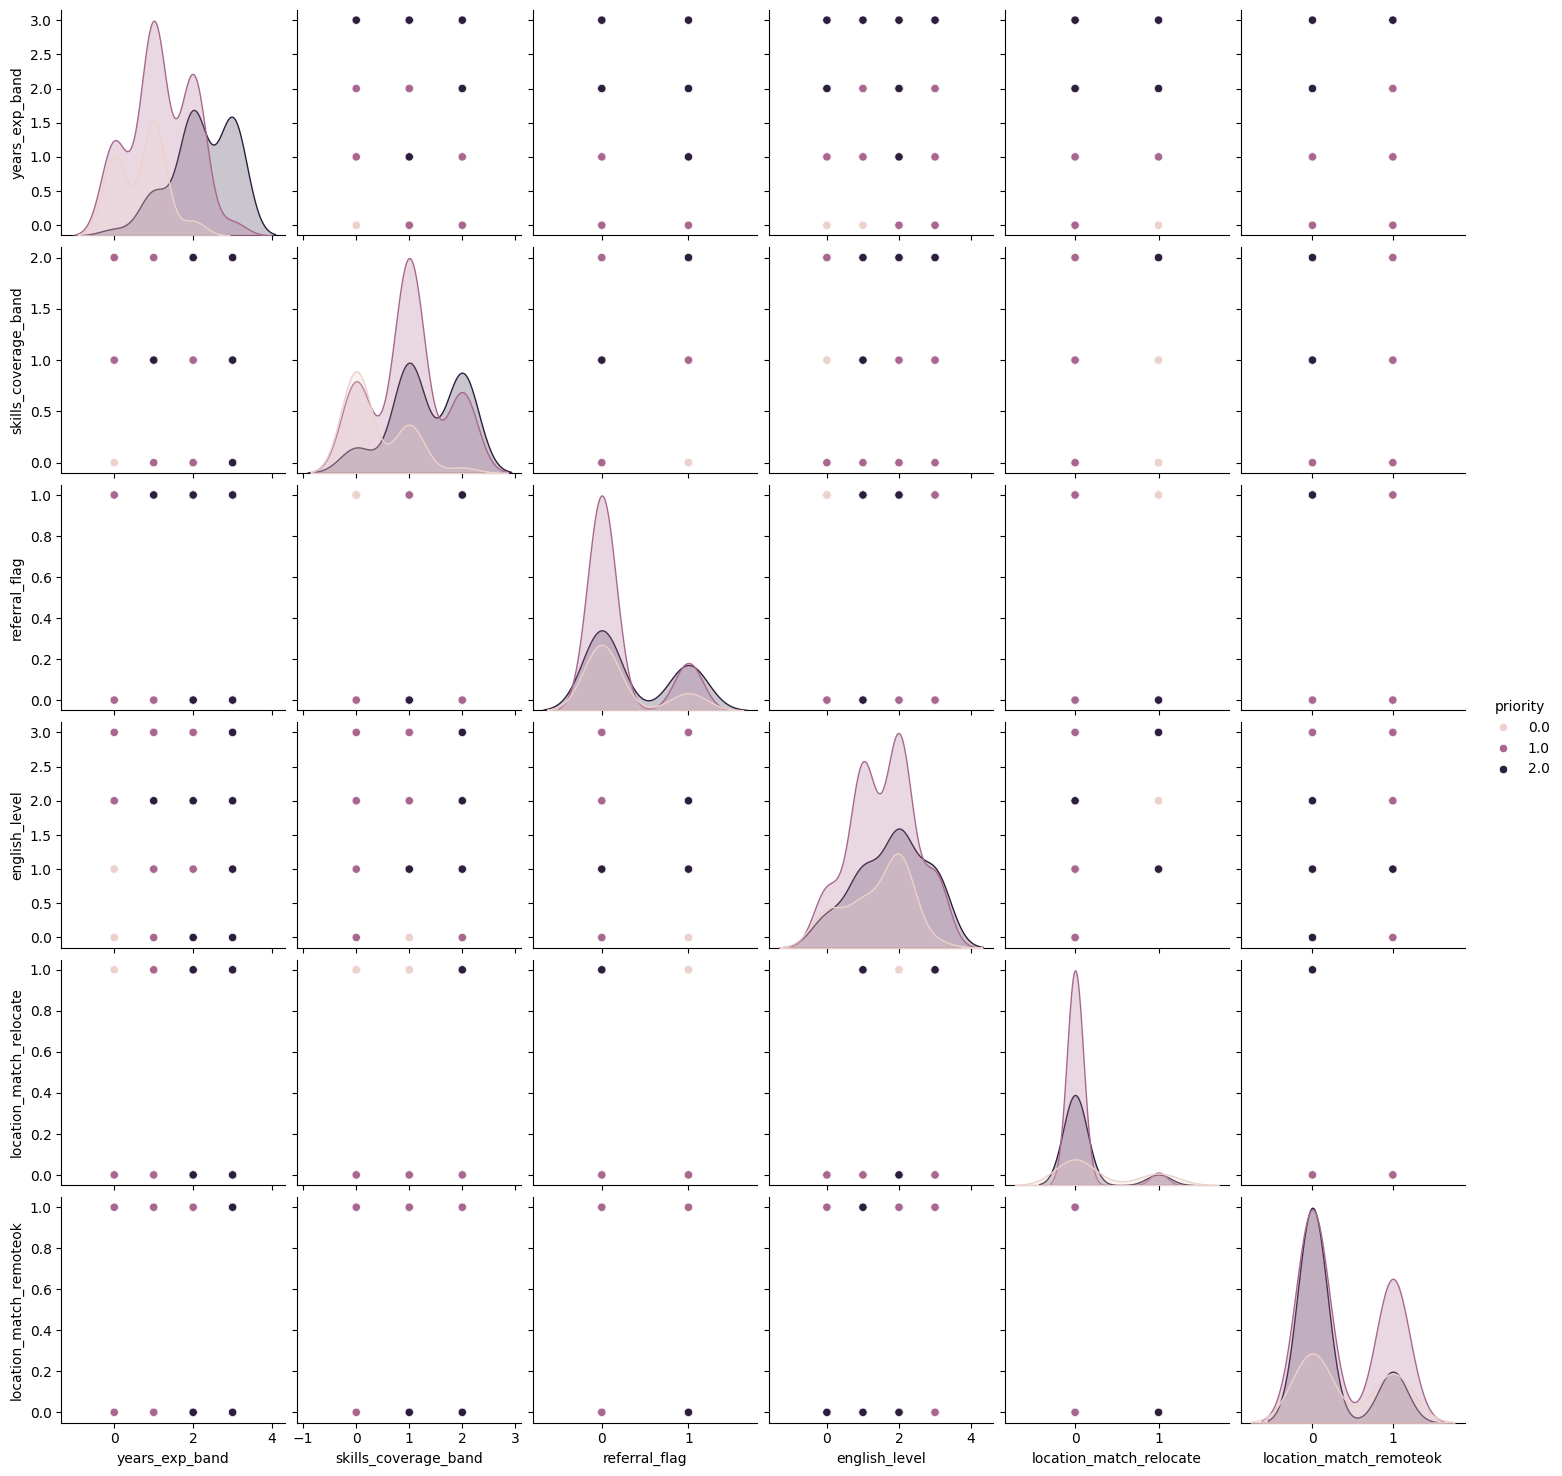

In [103]:
sns.pairplot(df, hue='priority',diag_kind="kde")  # kde = densité, hist = histogramme
plt.show()

In [104]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Exemple : charger ton dataset
# df = pd.read_csv("dataset.csv")

# =====================
# 1️⃣ Séparer features et target
# =====================
# Ici je suppose que ta variable cible est "priority"
X = df.drop(columns=["priority"])
y = df["priority"]

# =====================
# 2️⃣ Train/Test Split
# =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =====================
# 3️⃣ Entraînement Random Forest
# =====================
rf = RandomForestClassifier(
    n_estimators=200,   # nombre d’arbres
    max_depth=None,     # profondeur illimitée (peut être réglée)
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [105]:
y_pred = rf.predict(X_test)

print(" Accuracy:", accuracy_score(y_test, y_pred))
print("\n Rapport de classification:")
print(classification_report(y_test, y_pred))

 Accuracy: 0.9

 Rapport de classification:
              precision    recall  f1-score   support

         0.0       1.00      0.83      0.91         6
         1.0       0.88      0.93      0.90        15
         2.0       0.89      0.89      0.89         9

    accuracy                           0.90        30
   macro avg       0.92      0.89      0.90        30
weighted avg       0.90      0.90      0.90        30



/tmp/ipython-input-3016855242.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="years_exp_band", data=df, palette="Blues")


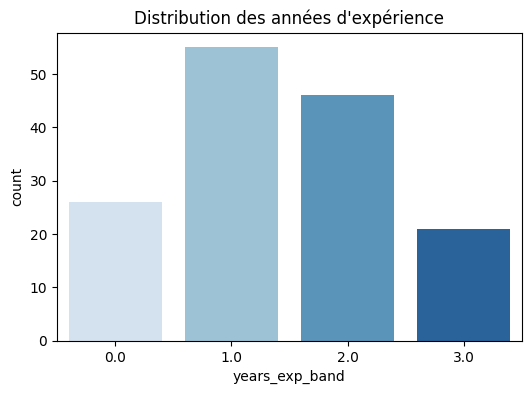

In [106]:
plt.figure(figsize=(6,4))
sns.countplot(x="years_exp_band", data=df, palette="Blues")
plt.title("Distribution des années d'expérience")
plt.show()

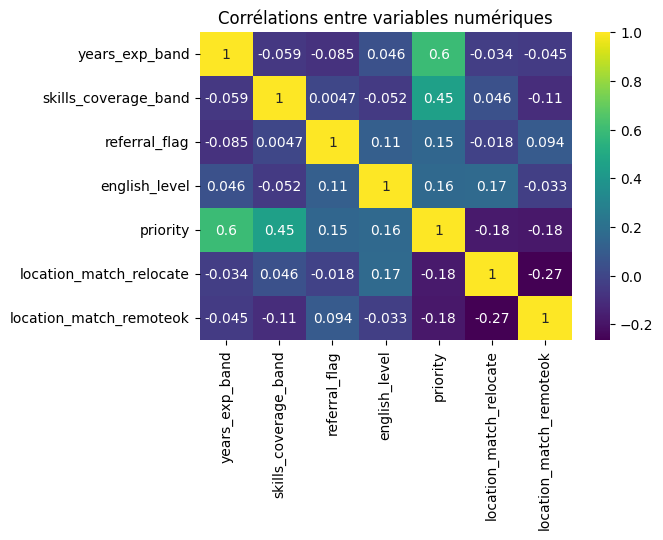

In [107]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="viridis")
plt.title("Corrélations entre variables numériques")
plt.show()


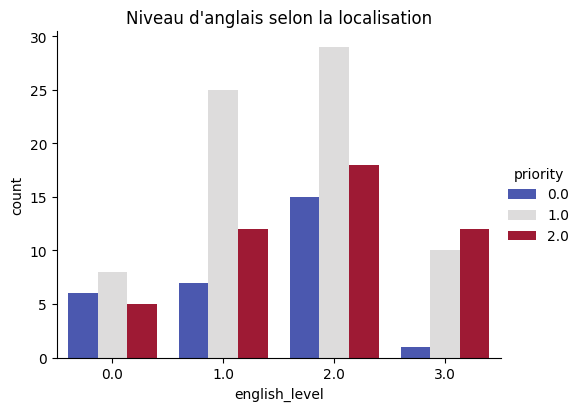

In [108]:
sns.catplot(
    data=df, kind="count",
    x="english_level", hue="priority",
    palette="coolwarm", height=4, aspect=1.3
)
plt.title("Niveau d'anglais selon la localisation")
plt.show()

/tmp/ipython-input-2341233165.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-2341233165.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


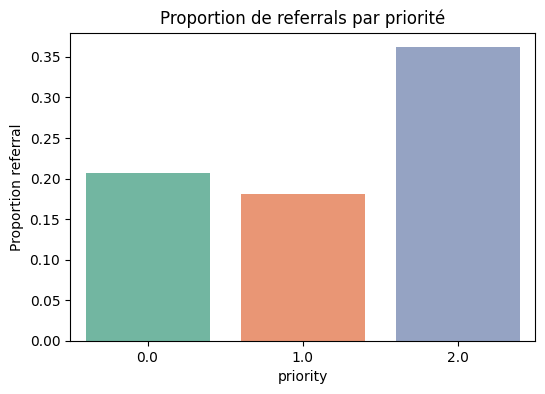

In [109]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="priority", y="referral_flag",
    estimator="mean", ci=None, palette="Set2"
)
plt.title("Proportion de referrals par priorité")
plt.ylabel("Proportion referral")
plt.show()

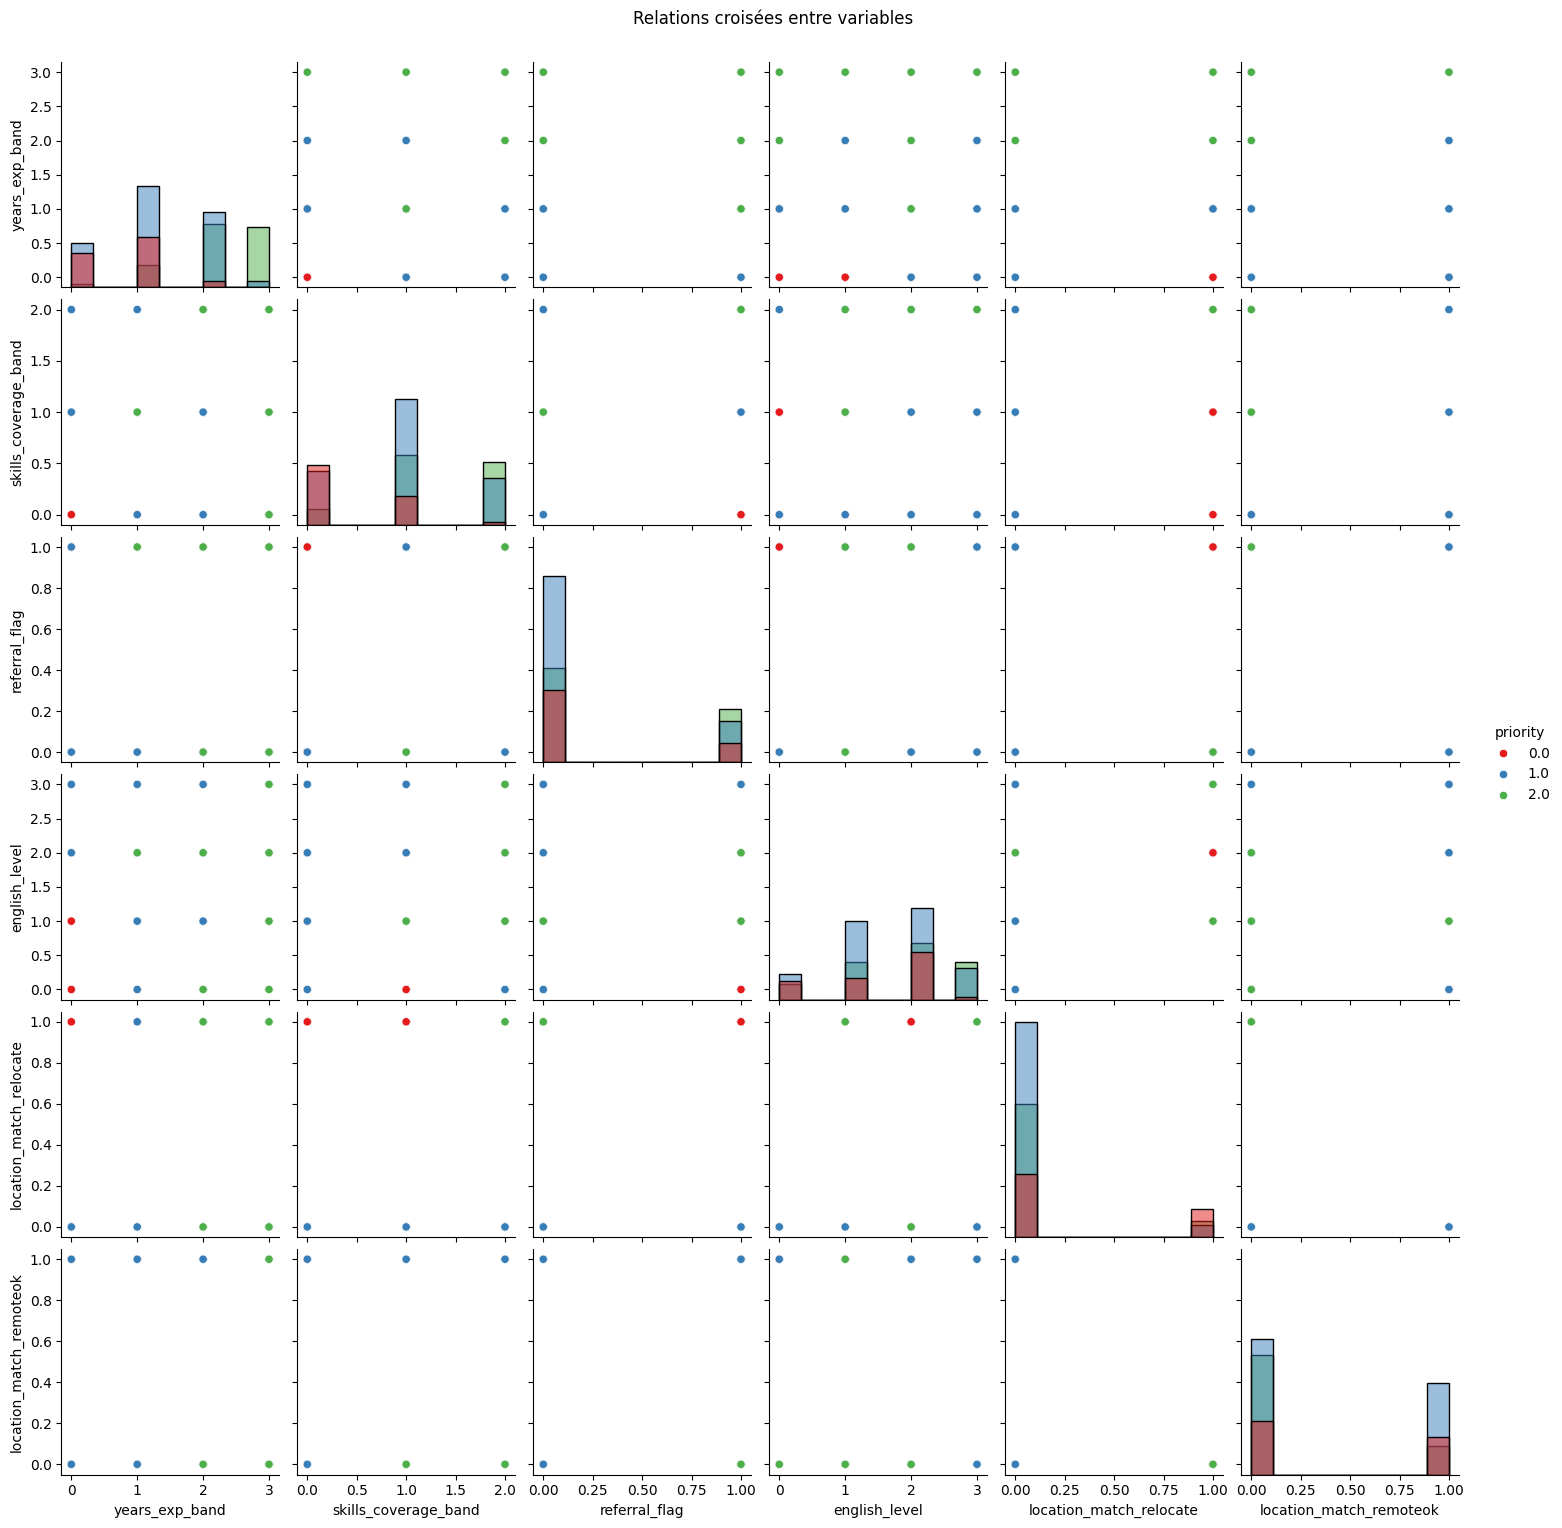

In [110]:
sns.pairplot(
    df,
    hue="priority",
    diag_kind="hist",
    palette="Set1"
)
plt.suptitle("Relations croisées entre variables", y=1.02)
plt.show()

/tmp/ipython-input-100412776.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Random Forest"], y=[acc], palette="Blues")


(0.0, 1.0)

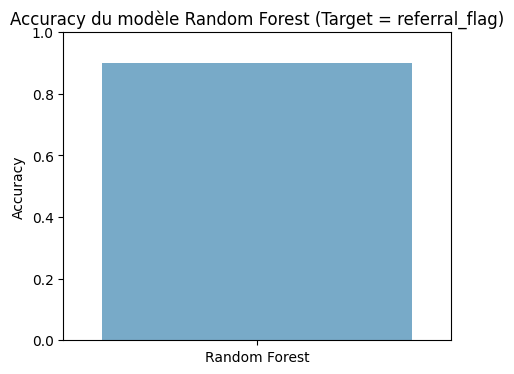

In [111]:
acc = accuracy_score(y_test, y_pred)

# ----------------------------
# Visualisation
# ----------------------------
plt.figure(figsize=(5,4))
sns.barplot(x=["Random Forest"], y=[acc], palette="Blues")
plt.title("Accuracy du modèle Random Forest (Target = referral_flag)")
plt.ylabel("Accuracy")
plt.ylim(0,1)

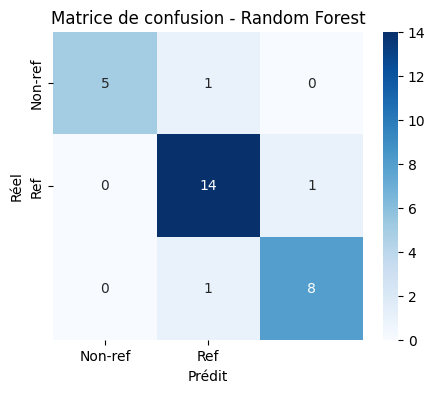

In [112]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-ref','Ref'], yticklabels=['Non-ref','Ref'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de confusion - Random Forest')
plt.show()

In [113]:
import pickle

# Sauvegarder le modèle
with open("logreg_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print(" Modèle sauvegardé dans logreg_model.pkl")


 Modèle sauvegardé dans logreg_model.pkl


In [115]:
import pandas as pd

# Supposons que ton dataset clean soit dans la variable `df_clean`
df.to_csv("dataset_clean.csv", index=False)
print("Dataset clean sauvegardé en CSV !")

Dataset clean sauvegardé en CSV !
